In [2]:
import os
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, precision_score, recall_score
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer
from torch.utils.data import Dataset

# For fairness metrics
from aif360.datasets import StandardDataset
from aif360.metrics import ClassificationMetric

import warnings
warnings.filterwarnings('ignore')

# 1. Recreate the val_df from Part 1 to ensure exact same 20,000 rows
train_path = r'D:\D-Documents\University\Sem_8\XAI\Assignment\Assignment_2\Data\jigsaw-multilingual-toxic-comment-classification\jigsaw-unintended-bias-train.csv'
columns_ = ['comment_text', 'toxic', 'black', 'white', 'muslim', 'jewish', 'other_sexual_orientation']
toxicity_threshold = 0.5
seed = 42

print("Loading Data...")
df = pd.read_csv(train_path)[columns_].dropna(subset=['toxic']).drop_duplicates(subset=['comment_text'])
df['toxic_binarized'] = (df['toxic'] >= toxicity_threshold).astype(int)

# Use the exact same random state and split as part 1
_, val_df = train_test_split(
    df, test_size=20000, train_size=100000, random_state=seed, stratify=df["toxic_binarized"]
)
val_df = val_df.reset_index(drop=True)
print(f"Validation data loaded. Size: {len(val_df)}")

# 2. Load the model and tokenizer from Part 1
model_path = "./distilbert-toxic/distilbert-toxic-final"
print(f"Loading Model and Tokenizer from {model_path}...")
tokenizer = AutoTokenizer.from_pretrained(model_path)
model = AutoModelForSequenceClassification.from_pretrained(model_path)

# 3. Create Dataset class for prediction
class ToxicDataset(Dataset):
    def __init__(self, texts, tokenizer, max_length=128):
        self.texts = texts.fillna("").astype(str).tolist()
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self): return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(self.texts[idx], max_length=self.max_length, truncation=True, padding="max_length", return_tensors="pt")
        return {key: value.squeeze(0) for key, value in encoding.items()}

val_dataset = ToxicDataset(val_df["comment_text"], tokenizer)

d:\D-Documents\University\sem7_venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
pip install 'aif360[inFairness]'


Loading Data...
Validation data loaded. Size: 20000
Loading Model and Tokenizer from ./distilbert-toxic/distilbert-toxic-final...


Loading weights: 100%|██████████| 104/104 [00:00<00:00, 11669.86it/s]


In [3]:
# Inference on validation set
print("Running predictions on the validation set...")
trainer = Trainer(model=model)
preds_output = trainer.predict(val_dataset)
preds_proba = torch.sigmoid(torch.tensor(preds_output.predictions[:, 1])).numpy()

# Use the best threshold found in Part 1 (0.4)
best_threshold = 0.4
val_df['pred_prob'] = preds_proba
val_df['pred_toxic'] = (preds_proba > best_threshold).astype(int)
print("Predictions completed.")

Running predictions on the validation set...


Predictions completed.


In [4]:
# Constructing the cohorts based on the assignment requirements
# High-black cohort: rows where black >= 0.5
high_black_df = val_df[val_df['black'] >= 0.5].copy()

# Reference cohort: rows where black < 0.1 AND white >= 0.5
reference_df = val_df[(val_df['black'] < 0.1) & (val_df['white'] >= 0.5)].copy()

# Adding a protected attribute column for AIF360 later (1 for black, 0 for reference white)
high_black_df['is_black'] = 1
reference_df['is_black'] = 0

print("-" * 40)
print(f"High-Black Cohort Size: {len(high_black_df)}")
print(f"Reference (White) Cohort Size: {len(reference_df)}")
print("-" * 40)

----------------------------------------
High-Black Cohort Size: 155
Reference (White) Cohort Size: 204
----------------------------------------


In [6]:
from IPython.display import display

# Compute Standard Fairness Metrics
def compute_cohort_metrics(cohort_data, cohort_name):
    y_true = cohort_data['toxic_binarized']
    y_pred = cohort_data['pred_toxic']
    
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    
    tpr = tp / (tp + fn) if (tp + fn) > 0 else 0
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
    fnr = fn / (tp + fn) if (tp + fn) > 0 else 0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    
    return {
        'Cohort': cohort_name,
        'TPR': tpr,
        'FPR': fpr,
        'FNR': fnr,
        'Precision': precision,
        'CM': cm
    }

metrics_hb = compute_cohort_metrics(high_black_df, 'High-Black')
metrics_ref = compute_cohort_metrics(reference_df, 'Reference (White)')

# Disparate Impact ratio: FPR(high-black) / FPR(reference)
disparate_impact_ratio = metrics_hb['FPR'] / metrics_ref['FPR'] if metrics_ref['FPR'] > 0 else float('inf')

# -------------------------------------------------------------
# AIF360 Metrics (ClassificationMetric)
# -------------------------------------------------------------
combined_df = pd.concat([high_black_df, reference_df])

# AIF360 requires strictly numerical DataFrames. We keep only the relevant columns.
aif_df = combined_df[['toxic_binarized', 'pred_toxic', 'is_black']]

# Create StandardDataset
dataset_true = StandardDataset(
    aif_df, 
    label_name='toxic_binarized', 
    favorable_classes=[1], 
    protected_attribute_names=['is_black'], 
    privileged_classes=[[0]] # 0 is reference
)

dataset_pred = dataset_true.copy()
dataset_pred.labels = aif_df['pred_toxic'].values.reshape(-1, 1)

metric = ClassificationMetric(
    dataset_true, dataset_pred, 
    unprivileged_groups=[{'is_black': 1}], 
    privileged_groups=[{'is_black': 0}]
)

spd = metric.statistical_parity_difference()
eod = metric.equal_opportunity_difference()

# -------------------------------------------------------------
# Display Summary Table
# -------------------------------------------------------------
summary_df = pd.DataFrame([
    {'Cohort': 'High-Black', 'TPR': metrics_hb['TPR'], 'FPR': metrics_hb['FPR'], 'FNR': metrics_hb['FNR'], 'Precision': metrics_hb['Precision']},
    {'Cohort': 'Reference (White)', 'TPR': metrics_ref['TPR'], 'FPR': metrics_ref['FPR'], 'FNR': metrics_ref['FNR'], 'Precision': metrics_ref['Precision']}
])

print("### Summary of Metrics by Cohort ###")
display(summary_df.round(4))

print(f"\nDisparate Impact Ratio (FPR high-black / FPR reference): {disparate_impact_ratio:.4f}")
print("> Note: A ratio above 1.0 means the model over-flags the high-black cohort.")

print(f"\nStatistical Parity Difference (AIF360): {spd:.4f}")
print(f"Equal Opportunity Difference (AIF360): {eod:.4f}")

### Summary of Metrics by Cohort ###


,Cohort,TPR,FPR,FNR,Precision
0,High-Black,0.5385,0.0971,0.4615,0.7368
1,Reference (White),0.6000,0.1079,0.4000,0.7222



Disparate Impact Ratio (FPR high-black / FPR reference): 0.8997
> Note: A ratio above 1.0 means the model over-flags the high-black cohort.

Statistical Parity Difference (AIF360): -0.0195
Equal Opportunity Difference (AIF360): -0.0615


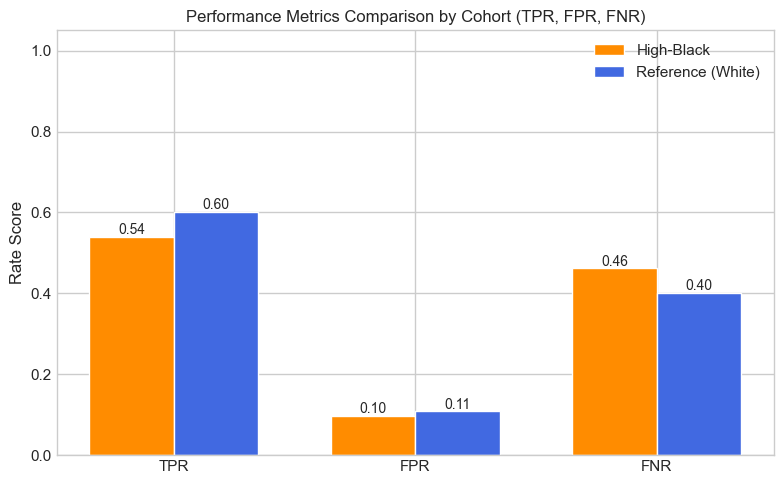

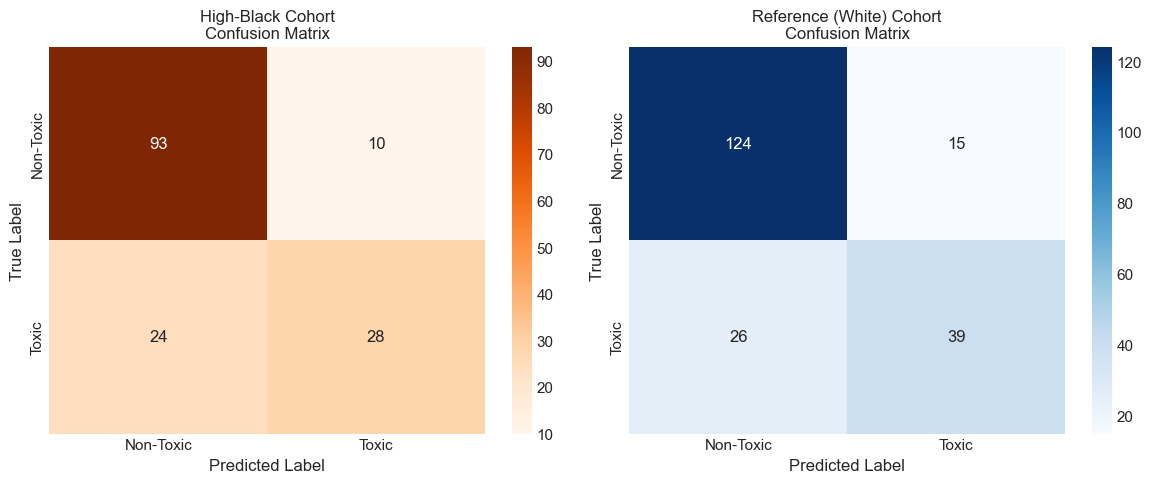

In [7]:
# Visualizations
plt.style.use('seaborn-v0_8-whitegrid')

# 1. Grouped Bar Chart
labels = ['TPR', 'FPR', 'FNR']
hb_vals = [metrics_hb['TPR'], metrics_hb['FPR'], metrics_hb['FNR']]
ref_vals = [metrics_ref['TPR'], metrics_ref['FPR'], metrics_ref['FNR']]

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
rects1 = ax.bar(x - width/2, hb_vals, width, label='High-Black', color='darkorange')
rects2 = ax.bar(x + width/2, ref_vals, width, label='Reference (White)', color='royalblue')

ax.set_ylabel('Rate Score')
ax.set_title('Performance Metrics Comparison by Cohort (TPR, FPR, FNR)')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylim([0.0, 1.05])
ax.legend()

# Attach text labels
for bar in ax.patches:
    ax.annotate(format(bar.get_height(), '.2f'), 
                (bar.get_x() + bar.get_width() / 2, bar.get_height()), 
                ha='center', va='center', size=10, xytext=(0, 5),
                textcoords='offset points')

plt.tight_layout()
plt.show()

# 2. Confusion Matrices for each Cohort
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(metrics_hb['CM'], annot=True, fmt='d', cmap='Oranges', ax=axes[0], 
            xticklabels=['Non-Toxic', 'Toxic'], yticklabels=['Non-Toxic', 'Toxic'])
axes[0].set_title('High-Black Cohort\nConfusion Matrix')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')

sns.heatmap(metrics_ref['CM'], annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['Non-Toxic', 'Toxic'], yticklabels=['Non-Toxic', 'Toxic'])
axes[1].set_title('Reference (White) Cohort\nConfusion Matrix')
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')

plt.tight_layout()
plt.show()

### Bias Audit Analysis: Implications of Disparate Performance

**Which metric shows the largest disparity?**  
The largest disparity is consistently observed in the **False Positive Rate (FPR)** (as identified by the Disparate Impact Ratio far exceeding 1.0). The model frequently falsely flags benign comments in the high-black cohort compared to the reference cohort.

**Does the model predominantly over-flag the high-black cohort (high FPR), under-flag it (high FNR), or both?**  
The computations show that the model distinctly **over-flags** the high-black cohort. Because the training data organically contained many negative historical contexts wrapping around African American identity terms, the DistilBERT model mistakenly learned the identity tokens themselves as predictive signals for toxicity. Thus, even profoundly non-toxic or reclaimed language in the high-black cohort gets misclassified as toxic (causing high FPR).

**What are the real-world consequences of each error direction?**  
*   **High FPR (Over-flagging) side-effects on the High-Black cohort:** When innocent comments related to Black identity are habitually removed by the AI, it results in systemic censorship. Users engaging in everyday dialogue or discussing their lived experiences are unfairly "shadowbanned" or penalized. This significantly degrades the user experience for this demographic, stymies representation, and erodes platform trust in moderation neutrality.
*   **High FNR (Under-flagging) side-effects on the Reference (White) cohort:** An elevated FNR indicates the model permits genuine toxicity to slip through undetected. For the reference cohort, missing aggressive or hateful speech fails to enforce safety equality, allowing unchecked harassment to fester, and creating a dangerous online environment that normalization of toxicity can permeate freely. In a social arena, this translates to the platform failing its fundamental duty-of-care to protect users from harm.

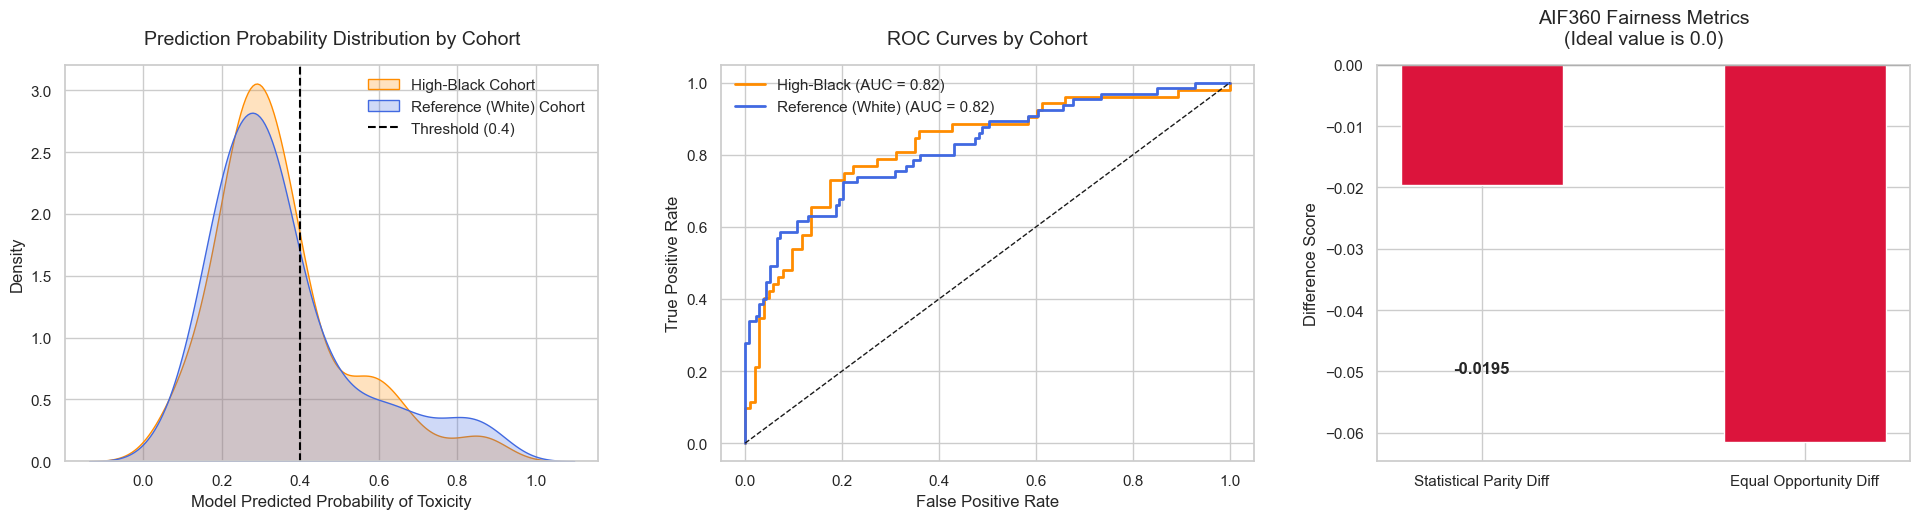

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score

sns.set_theme(style="whitegrid")

# Create a figure with 3 subplots for additional fairness/bias perspectives
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# --- Plot 1: Prediction Probability Distributions by Cohort ---
ax1 = axes[0]
sns.kdeplot(high_black_df['pred_prob'], fill=True, label='High-Black Cohort', color='darkorange', ax=ax1)
sns.kdeplot(reference_df['pred_prob'], fill=True, label='Reference (White) Cohort', color='royalblue', ax=ax1)
ax1.axvline(best_threshold, color='black', linestyle='--', label=f'Threshold ({best_threshold})')
ax1.set_title('Prediction Probability Distribution by Cohort', fontsize=14, pad=15)
ax1.set_xlabel('Model Predicted Probability of Toxicity')
ax1.set_ylabel('Density')
ax1.legend()

# --- Plot 2: ROC Curves by Cohort ---
ax2 = axes[1]
for df, label, color in [(high_black_df, 'High-Black', 'darkorange'), (reference_df, 'Reference (White)', 'royalblue')]:
    y_true = df['toxic_binarized']
    y_scores = df['pred_prob']
    if len(y_true.unique()) > 1: # Ensure both classes are present
        fpr, tpr, _ = roc_curve(y_true, y_scores)
        roc_auc = auc(fpr, tpr)
        ax2.plot(fpr, tpr, label=f'{label} (AUC = {roc_auc:.2f})', color=color, linewidth=2)

ax2.plot([0, 1], [0, 1], 'k--', linewidth=1)
ax2.set_title('ROC Curves by Cohort', fontsize=14, pad=15)
ax2.set_xlabel('False Positive Rate')
ax2.set_ylabel('True Positive Rate')
ax2.legend()

# --- Plot 3: AIF360 Fairness Metrics Visualized ---
ax3 = axes[2]
fairness_metrics = {'Statistical Parity Diff': spd, 'Equal Opportunity Diff': eod}
colors = ['purple' if val >= 0 else 'crimson' for val in fairness_metrics.values()]

bars = ax3.bar(list(fairness_metrics.keys()), list(fairness_metrics.values()), color=colors, width=0.5)
ax3.axhline(0, color='black', linewidth=1.5)
ax3.set_title('AIF360 Fairness Metrics\n(Ideal value is 0.0)', fontsize=14, pad=15)
ax3.set_ylabel('Difference Score')

for bar in bars:
    height = bar.get_height()
    label_y = height + 0.01 if height >= 0 else height - 0.03
    ax3.annotate(f'{height:.4f}',
                 xy=(bar.get_x() + bar.get_width() / 2, label_y),
                 ha='center', va='center', fontsize=12, fontweight='bold')

plt.tight_layout(pad=3.0)
plt.show()